In [19]:
import pandas as pd
from Bio import Phylo

# --- Input files ---
host_tree_file = "host_taxonomy_tree_gut.newick"
virus_tree_file = "virus_tree_human_gut.newick"
interaction_tsv = "gut_dataset_hic_gtdb.tsv"
output_csv = "interaction_matrix_gut.csv"

# --- Load the interaction table ---
df = pd.read_csv(interaction_tsv, sep="\t")

# --- Extract phages and hosts from the TSV ---
phages = df['Phage'].unique()
hosts = df['MAGs'].unique()

# --- Parse Newick trees using Bio.Phylo ---
host_tree = Phylo.read(host_tree_file, "newick")
virus_tree = Phylo.read(virus_tree_file, "newick")

# Get ordered leaf names
ordered_hosts = [term.name for term in host_tree.get_terminals() if term.name in hosts]
ordered_phages = [term.name for term in virus_tree.get_terminals() if term.name in phages]

# --- Initialize empty interaction matrix ---
interaction_matrix = pd.DataFrame(0, index=ordered_phages, columns=ordered_hosts)

# --- Fill the matrix with interactions ---
for _, row in df.iterrows():
    phage = row['Phage']
    host = row['MAGs']
    if phage in interaction_matrix.index and host in interaction_matrix.columns:
        interaction_matrix.loc[phage, host] = 1

# --- Save to CSV ---
interaction_matrix.to_csv(output_csv)
print(f"Interaction matrix saved to {output_csv}")


Interaction matrix saved to interaction_matrix_gut.csv


In [20]:
import argparse
import os
import numpy as np
from Bio import Phylo
import sys
import os
import copy
import math
import json
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to sys.path
sys.path.append(os.path.abspath(".."))
import importlib
# importlib.reload(sys.modules['simulation_utils'])
from simulation_utils import *

In [21]:
def read_interaction_matrix(csv_file, host_tree_file, virus_tree_file):
    """
    Read host-virus interaction matrix CSV and reorder according to tree leaves.
    Treat viruses as parasites.
    
    Returns:
        cell_state: dict with keys (virus, host) -> 0/1
        host_tree: Bio.Phylo tree object
        virus_tree: Bio.Phylo tree object
    """

    # Load trees
    host_tree = Phylo.read(host_tree_file, "newick")
    virus_tree = Phylo.read(virus_tree_file, "newick")

    # Get leaf order
    host_order = [t.name for t in host_tree.get_terminals()]
    virus_order = [t.name for t in virus_tree.get_terminals()]

    print(f"Number of hosts in tree: {len(host_order)}")
    print(f"Number of viruses in tree: {len(virus_order)}")

    # Load interaction matrix CSV
    df = pd.read_csv(csv_file, index_col=0)  # assuming rows=viruses, columns=hosts
    # Ensure names match the expected tree leaf names
    df = df.loc[df.index.intersection(virus_order), df.columns.intersection(host_order)]

    # Reorder according to tree leaves
    df = df.reindex(index=virus_order, columns=host_order, fill_value=0)

    # Build cell_state dictionary
    cell_state = {}
    for virus in virus_order:
        for host in host_order:
            cell_state[(virus, host)] = int(df.at[virus, host])

    return cell_state, host_tree, virus_tree







outdir = "experiments"
association_csv = "interaction_matrix_gut.csv"
host_tree = "host_taxonomy_tree_gut.newick"
virus_tree = "virus_tree_human_gut.newick"


os.makedirs(outdir, exist_ok=True)

# Read associations + trees
cell_state, base_host_tree, base_par_tree = read_interaction_matrix(
    association_csv, host_tree, virus_tree
)

base_host_tree = rescale_tree(base_host_tree)
base_par_tree = rescale_tree(base_par_tree)

# print (base_host_tree)
# print (base_par_tree)

host_leaves = [t.name for t in base_host_tree.get_terminals()]
par_leaves = [t.name for t in base_par_tree.get_terminals()]

out = {
    "host_trees": [copy.deepcopy(base_host_tree) for _ in range(len(par_leaves))],
    "par_trees": [copy.deepcopy(base_par_tree) for _ in range(len(host_leaves))],
    "cell_state": cell_state,
    "host_leaves": host_leaves,
    "par_leaves": par_leaves
}

# Build the matrix
mat, parasites, hosts = get_interaction_matrix(out)

# Save the matrix visualization
plot_matrix(mat, parasites, hosts, filename=os.path.join(outdir, "original_matrix_gut.svg"))

Number of hosts in tree: 84
Number of viruses in tree: 84
Matrix saved as experiments/original_matrix_gut.svg


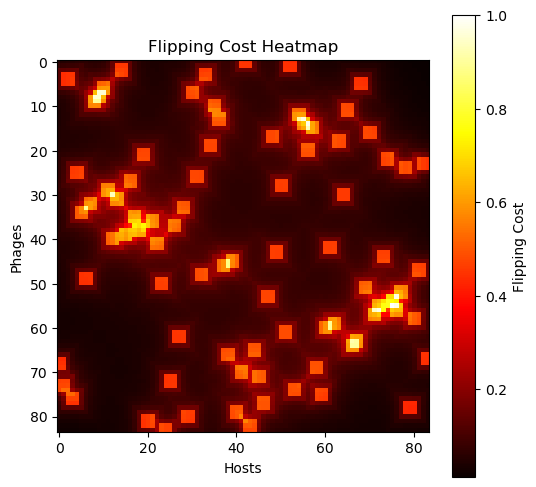

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def compute_flipping_cost_matrix(mat):
    """
    Compute a flipping-cost matrix for all cells in the binary matrix.
    Each cell's cost is proportional to number of nearby 1's, weighted by 1/distance^2.
    """
    n_rows, n_cols = mat.shape
    cost_mat = np.zeros_like(mat, dtype=float)

    # Pad matrix to simplify boundary handling
    pad = max(n_rows, n_cols)
    padded = np.pad(mat, pad_width=pad, mode='constant', constant_values=0)
    offset = pad

    for i in range(n_rows):
        for j in range(n_cols):
            total_score = 0.0
            max_k = max(n_rows, n_cols) // 2

            r_p, c_p = i + offset, j + offset

            for k in range(1, max_k + 1):
                top, bottom = r_p - k, r_p + k
                left, right = c_p - k, c_p + k

                # extract boundary cells
                boundary = np.concatenate([
                    padded[top, left:right+1],
                    padded[bottom, left:right+1],
                    padded[top+1:bottom, left],
                    padded[top+1:bottom, right]
                ])

                num_ones = np.sum(boundary == 1)
                total_score += num_ones / (k ** 2)

            cost_mat[i, j] = total_score + mat[i, j]

    # Optional: normalize for visualization
    if cost_mat.max() > 0:
        cost_mat = cost_mat / cost_mat.max()

    return cost_mat


def plot_heatmap(matrix, title="Flipping Cost Heatmap"):
    """Simple matrix heatmap plot."""
    plt.figure(figsize=(6, 6))
    plt.imshow(matrix, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Flipping Cost')
    plt.title(title)
    plt.xlabel("Hosts")
    plt.ylabel("Phages")
    plt.show()

flipping_cost_matrix = compute_flipping_cost_matrix(mat)
plot_heatmap(flipping_cost_matrix, title="Flipping Cost Heatmap")

In [26]:
# count how many entries are less than or equal to 1
flipping_cost_matrix[0,:]

array([0.0126162 , 0.01285063, 0.01326898, 0.01359102, 0.01411792,
       0.01472443, 0.01528617, 0.01612554, 0.01636276, 0.01663188,
       0.0169397 , 0.01729512, 0.01783797, 0.01724275, 0.0170942 ,
       0.01730587, 0.01770752, 0.01847172, 0.01984083, 0.02187006,
       0.02494365, 0.02990723, 0.03841357, 0.05662026, 0.10820262,
       0.38544019, 0.38612682, 0.38693997, 0.11087544, 0.06032042,
       0.04267471, 0.03476102, 0.03085862, 0.02911444, 0.02868848,
       0.02922658, 0.03084871, 0.0333835 , 0.0378385 , 0.04647833,
       0.04687067, 0.0476863 , 0.04864855, 0.05018003, 0.05223223,
       0.05515497, 0.05674239, 0.05898703, 0.05380138, 0.05444338,
       0.06082939, 0.07783327, 0.07764139, 0.07797621, 0.07847112,
       0.0798592 , 0.08256718, 0.08690186, 0.07632999, 0.08130282,
       0.10094594, 0.16557063, 0.2137173 , 0.48834044, 0.48691664,
       0.48578745, 0.1571264 , 0.08729578, 0.06075064, 0.04750183,
       0.0401147 , 0.03559271, 0.03255318, 0.03067539, 0.02948

In [23]:
out_original = out.copy()  # Keep original for each run

In [24]:
def matrix_builder(out, r01_h, r10_h, r01_p, r10_p):
    host_W_matrices = []
    for t in out["host_trees"]:
        W, nodes = build_weight_matrix(t, r01_h, r10_h, scale=100.0)
        # scale W
        # W[W!=0] =  np.inf
        W = W*100
        host_W_matrices.append((W, nodes))

    # Build weight matrices for each host’s parasite tree
    par_W_matrices = []
    for t in out["par_trees"]:
        W, nodes = build_weight_matrix(t, r01_p, r10_p, scale=100.0)
        # scale W
        W = W*100
        par_W_matrices.append((W, nodes))
    # Flip cost matrix
    # flip_cost_matrix = build_flip_cost_matrix(len(out["par_leaves"]), len(out["host_leaves"]), cost=100.0)
    flip_cost_matrix=-np.log(flipping_cost_matrix)
    return host_W_matrices, par_W_matrices, flip_cost_matrix
out_corrupt = out_original.copy()
hidden_cells = []
# for virus in parasites:
#     for host in hosts:
#         if out_corrupt["cell_state"][(virus, host)] == 1 and host in betacov_true_hosts_id:
#             hidden_cells.append((virus, host))
#             out_corrupt["cell_state"][(virus, host)] = 0
seed = 42
r01_p, r10_p, r01_h, r10_h = 0.7,0.3,0.5,0.5
host_W_matrices, par_W_matrices, flip_cost_matrix = matrix_builder(out_corrupt, r01_h, r10_h, r01_p, r10_p)

In [29]:
par_W_matrices[0][0]

array([[ 0.        , 58.00049236, 59.78062314, ...,  0.        ,
         0.        ,  0.        ],
       [58.00049236,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [59.78062314,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(200, 200))

In [25]:
def flip_specific_cells(mat, parasites, hosts, flip_targets):
    """
    Flip given cells (1->0) based on Phage-HOST pairs.
    Also set flip cost rules:
      - Flipped cells -> cost = 0.5
      - All other phage rows (not in flip targets) -> inf for all hosts
    
    Args:
        mat: numpy array, original matrix
        parasites: list of row labels (Phages)
        hosts: list of column labels (MAGs)
        flip_targets: list of tuples (Phage, MAGs) to flip
        flip_cost_matrix: numpy array (same shape as mat) to modify
    
    Returns:
        mat_corrupt: numpy array with specified cells flipped
        flipped_indices: list of (i,j) indices that were flipped
        flip_cost_matrix: modified cost matrix
    """
    mat_corrupt = mat.copy()
    flipped_indices = []

    parasite_idx = {p: i for i, p in enumerate(parasites)}
    host_idx = {h: j for j, h in enumerate(hosts)}

    # Track which phages are in flip targets
    targeted_phages = set()

    for phage, host in flip_targets:
        if phage in parasite_idx and host in host_idx:
            i, j = parasite_idx[phage], host_idx[host]
            # flip_cost_matrix[i, :] = 50
            targeted_phages.add(phage)
            if mat_corrupt[i, j] == 1:
                mat_corrupt[i, j] = 0
                # flip_cost_matrix[i, j] = 0.0
                flipped_indices.append((i, j))

    # Set inf for all non-targeted phage rows
    for p in parasites:
        if p not in targeted_phages:
            i = parasite_idx[p]
            # flip_cost_matrix[i, :] = 1
            mat_corrupt[i, :] = 1

    return mat_corrupt, flipped_indices

In [31]:

parasite_idx = {p: i for i, p in enumerate(parasites)}
host_idx = {h: j for j, h in enumerate(hosts)}
print (flip_cost_matrix[parasite_idx["k141_65862"],:])

KeyError: 'k141_65862'

In [32]:
#  count number of 1 s in the mat
print(np.sum(mat == 1))

101


In [17]:


flip_targets = [("k141_346380", "bin.99")]
# corrupt_mat, hidden, flip_cost_matrix = flip_specific_cells(mat, parasites, hosts, flip_targets, flip_cost_matrix)
corrupt_mat, hidden= flip_specific_cells(mat, parasites, hosts, flip_targets)

# find the entries of the flip cost matrix that are greater than 0
# print(np.count_nonzero(flip_cost_matrix > 0))

# Save hidden cells for metrics
hidden_cells = [(parasites[i], hosts[j]) for i, j in hidden]

highlight_corrupted = {"corrupted": hidden_cells}
plot_matrix(corrupt_mat, parasites, hosts,
            filename=os.path.join(outdir, "corrupted_sample_cow.svg"),
            highlight=highlight_corrupted)

# Update out["cell_state"] with corrupted values
corrupt_cell_state = {}
for i, p in enumerate(parasites):
    for j, h in enumerate(hosts):
        corrupt_cell_state[(p, h)] = int(corrupt_mat[i, j])
out["cell_state"] = corrupt_cell_state



lambda_param, cut_result = binary_search_lambda(
    out, parasites, hosts, hidden_cells=hidden_cells,
    target_flips=3,
    host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
    flip_cost_matrix=flip_cost_matrix,
    tol=0, max_iter=20
)

Matrix saved as experiments/corrupted_sample_cow.svg
[iter 0] λ=0.5000 → flips=66
[iter 1] λ=0.2500 → flips=66
[iter 2] λ=0.1250 → flips=66
[iter 3] λ=0.0625 → flips=66
[iter 4] λ=0.0312 → flips=2
[iter 5] λ=0.0469 → flips=66
[iter 6] λ=0.0391 → flips=66
[iter 7] λ=0.0352 → flips=66
[iter 8] λ=0.0332 → flips=66
[iter 9] λ=0.0322 → flips=23
[iter 10] λ=0.0317 → flips=23
[iter 11] λ=0.0315 → flips=2
[iter 12] λ=0.0316 → flips=23
[iter 13] λ=0.0316 → flips=23
[iter 14] λ=0.0315 → flips=23
[iter 15] λ=0.0315 → flips=23
[iter 16] λ=0.0315 → flips=2
[iter 17] λ=0.0315 → flips=2
[iter 18] λ=0.0315 → flips=23
[iter 19] λ=0.0315 → flips=2

Best λ=0.0312 → flips=2, correct=1/3


In [26]:
import pandas as pd
import os
import numpy as np

# Load dataset
tsv_path = "gut_dataset_hic_gtdb.tsv"
df = pd.read_csv(tsv_path, sep="\t")

results = []  # collect outputs for all pairs

# Loop through each (Phage, MAGs) pair
for idx, row in df.iterrows():
    phage = row["Phage"]
    mag = row["MAGs"]

    flip_targets = [(phage, mag)]
    print(f"\n🧩 Processing pair {idx+1}/{len(df)}: {phage} ↔ {mag}")

    # Step 1: flip specific cell
    corrupt_mat, hidden = flip_specific_cells(mat, parasites, hosts, flip_targets)

    # Step 2: record hidden cells
    hidden_cells = [(parasites[i], hosts[j]) for i, j in hidden]

    # Step 3: visualize corrupted matrix
    # highlight_corrupted = {"corrupted": hidden_cells}
    # out_svg = os.path.join(outdir, f"corrupted_{phage}_{mag}.svg")
    # plot_matrix(
    #     corrupt_mat,
    #     parasites,
    #     hosts,
    #     filename=out_svg,
    #     highlight=highlight_corrupted,
    # )

    # Step 4: update out["cell_state"]
    corrupt_cell_state = {
        (p, h): int(corrupt_mat[i, j])
        for i, p in enumerate(parasites)
        for j, h in enumerate(hosts)
    }
    out["cell_state"] = corrupt_cell_state

    # Step 5: run optimization
    lambda_param, cut_result = binary_search_lambda(
        out,
        parasites,
        hosts,
        hidden_cells=hidden_cells,
        target_flips=3,
        host_W_matrices=host_W_matrices,
        par_W_matrices=par_W_matrices,
        flip_cost_matrix=flip_cost_matrix,
        tol=0,
        max_iter=20,
    )

    new_mat = cut_result["new_matrix"]
    new_cell_state = cut_result["new_cell_state"]
    flips = cut_result["flips"]

    # highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
    print(f"Number of flips performed: {len(flips)}")
    # for p, h, old, new in flips:
    #     print(f"Cell ({p},{h}): {old} -> {new}")

    # ---------------------------
    # Step 3: Save recovered matrix with algorithm flips
    # ---------------------------
    # plot_matrix(new_mat, parasites, hosts,
    #             filename=os.path.join(outdir, "flipped_matrix.svg"),
    #             highlight=highlight_flipped)






    # inside main(), after you have flips and hidden_cells
    metrics = compute_metrics(hidden_cells, flips)
    print("Metrics:", metrics)

    # Step 6: collect result
    results.append({
        "Phage": phage,
        "MAG": mag,
        "lambda": lambda_param,
        "metrics": metrics
        
    })

    print(f"✅ Finished {phage} - {mag}, λ={lambda_param}, metrics={metrics}")

# Optional: save summary
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(outdir, "flip_experiment_summary_3flips_gut.tsv"), sep="\t", index=False)

print("\n🎉 All pairs processed and results saved.")



🧩 Processing pair 1/84: k141_148646 ↔ bin.98
[iter 0] λ=0.5000 → flips=84
[iter 1] λ=0.2500 → flips=84
[iter 2] λ=0.1250 → flips=84
[iter 3] λ=0.0625 → flips=84
[iter 4] λ=0.0312 → flips=29
[iter 5] λ=0.0156 → flips=0
[iter 6] λ=0.0234 → flips=2
[iter 7] λ=0.0273 → flips=14
[iter 8] λ=0.0254 → flips=4
[iter 9] λ=0.0244 → flips=4
[iter 10] λ=0.0239 → flips=2
[iter 11] λ=0.0242 → flips=4
[iter 12] λ=0.0240 → flips=2
[iter 13] λ=0.0241 → flips=2
[iter 14] λ=0.0241 → flips=4
[iter 15] λ=0.0241 → flips=2
[iter 16] λ=0.0241 → flips=2
[iter 17] λ=0.0241 → flips=4
[iter 18] λ=0.0241 → flips=4
[iter 19] λ=0.0241 → flips=2

Best λ=0.0234 → flips=2, correct=0/3
Number of flips performed: 2
Metrics: {'precision': 0.0, 'recall': 0.0, 'f1': 0, 'TP': 0, 'FP': 2, 'FN': 1}
✅ Finished k141_148646 - bin.98, λ=0.0234375, metrics={'precision': 0.0, 'recall': 0.0, 'f1': 0, 'TP': 0, 'FP': 2, 'FN': 1}

🧩 Processing pair 2/84: k141_162918 ↔ bin.97
[iter 0] λ=0.5000 → flips=84
[iter 1] λ=0.2500 → flips=84
[ite

In [18]:

cut_result = solve_network_cut(out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
                                         flip_cost_matrix=flip_cost_matrix, lambda_param=lambda_param)
# ---------------------------
# Step 2: Run network cut recovery on corrupted input
# ---------------------------


new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]

highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")
# for p, h, old, new in flips:
#     print(f"Cell ({p},{h}): {old} -> {new}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
plot_matrix(new_mat, parasites, hosts,
            filename=os.path.join(outdir, "flipped_matrix_sample_cow.svg"),
            highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
metrics = compute_metrics(hidden_cells, flips)
print("Metrics:", metrics)

Number of flips performed: 2
Matrix saved as experiments/flipped_matrix_sample_cow.svg
Metrics: {'precision': 0.5, 'recall': 1.0, 'f1': 0.6666666666666666, 'TP': 1, 'FP': 1, 'FN': 0}
